# Typical NN implementation in Pytorch

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# load the dataset, split into input (X) and output (y) variables
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8]
y = dataset[:,8]

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

In [4]:
# define the model
class PimaClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(8, 12)
        self.act1 = nn.ReLU()
        self.hidden2 = nn.Linear(12, 8)
        self.act2 = nn.ReLU()
        self.output = nn.Linear(8, 1)
        self.act_output = nn.Sigmoid()

    # this must be explicitly implemented
    def forward(self, x):
        x = self.act1(self.hidden1(x))
        x = self.act2(self.hidden2(x))
        x = self.act_output(self.output(x))
        return x

model = PimaClassifier()
"""
Alternatively:
"""
model = nn.Sequential(
    nn.Linear(in_features=8, out_features=12),
    nn.ReLU(),
    nn.Linear(in_features=12, out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8, out_features=1),
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


### Trying out simple operations

In [32]:
torch.manual_seed(12)
linear_model = nn.Linear(in_features=8, out_features=1)

i = 10
batch_size = 10

Xbatch = X[i:i+batch_size]
y_pred = linear_model(Xbatch)
y_pred

tensor([[ -39.1607],
        [ -50.4657],
        [ -46.4201],
        [-109.4712],
        [ -59.9134],
        [ -32.6009],
        [ -54.5795],
        [ -36.1321],
        [ -40.7639],
        [ -43.1918]], grad_fn=<AddmmBackward0>)

In [34]:
torch.manual_seed(12)
linear_model = nn.Sequential(
    nn.Linear(in_features=8, out_features=1),
    nn.Sigmoid()
)

Xbatch = X[i:i+batch_size]
y_pred = linear_model(Xbatch)
y_pred

tensor([[9.8342e-18],
        [1.2106e-22],
        [6.9186e-21],
        [0.0000e+00],
        [9.5485e-27],
        [6.9438e-15],
        [1.9789e-24],
        [2.0326e-16],
        [1.9790e-18],
        [1.7461e-19]], grad_fn=<SigmoidBackward0>)

In [37]:
# checking individual weights
linear_model[0].weight

Parameter containing:
tensor([[-0.0243, -0.1890, -0.0334,  0.0616, -0.0646, -0.2636,  0.0971, -0.1824]],
       requires_grad=True)

### Training Block

In [24]:
# train the model
loss_fn   = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
batch_size = 10

for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        y_pred = model(Xbatch)
        ybatch = y[i:i+batch_size]
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# compute accuracy
y_pred = model(X)
accuracy = (y_pred.round() == y).float().mean()
print(f"Accuracy {accuracy}")

# make class predictions with the model
predictions = (model(X) > 0.5).int()
for i in range(5):
    print('%s => %d (expected %d)' % (X[i].tolist(), predictions[i], y[i]))

Accuracy 0.7708333134651184
[6.0, 148.0, 72.0, 35.0, 0.0, 33.599998474121094, 0.6269999742507935, 50.0] => 1 (expected 1)
[1.0, 85.0, 66.0, 29.0, 0.0, 26.600000381469727, 0.35100001096725464, 31.0] => 0 (expected 0)
[8.0, 183.0, 64.0, 0.0, 0.0, 23.299999237060547, 0.671999990940094, 32.0] => 1 (expected 1)
[1.0, 89.0, 66.0, 23.0, 94.0, 28.100000381469727, 0.16699999570846558, 21.0] => 0 (expected 0)
[0.0, 137.0, 40.0, 35.0, 168.0, 43.099998474121094, 2.2880001068115234, 33.0] => 1 (expected 1)


# Non-linear Classification Example

In [64]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import pandas as pd

# Generate non-linear data (two moons shape)
X, y = make_moons(n_samples=300, noise=0.14, random_state=42)

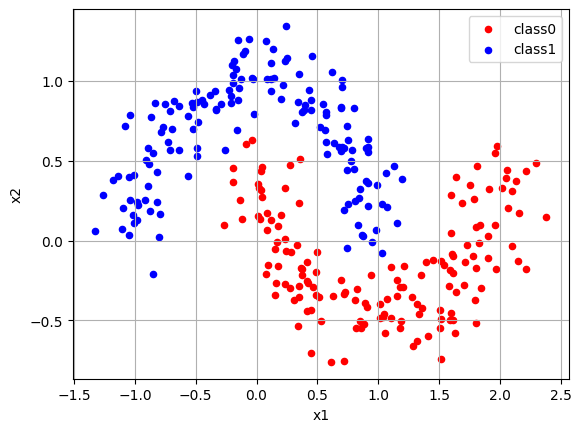

In [65]:
data = pd.DataFrame(X, columns=["x1", "x2"])
data['y'] = y

fig, ax = plt.subplots()

data.loc[data.y == 1].plot.scatter(x='x1', y='x2', c='red', label='class0', ax=ax)
data.loc[data.y == 0].plot.scatter(x='x1', y='x2', c='blue', label='class1', ax=ax)
ax.grid(True)

plt.show()

In [72]:
X = torch.FloatTensor(X)
y = torch.FloatTensor(y).reshape(-1, 1)

# Create a simple neural network with one hidden layer
model = nn.Sequential(
    nn.Linear(2, 10),  # Hidden layer with 10 units
    nn.ReLU(),
    # nn.Tanh(),
    # nn.Sigmoid(),        # Non-linear activation
    nn.Linear(10, 1),  # Output layer
    nn.Sigmoid()      # For binary classification
)

# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(100):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.7328


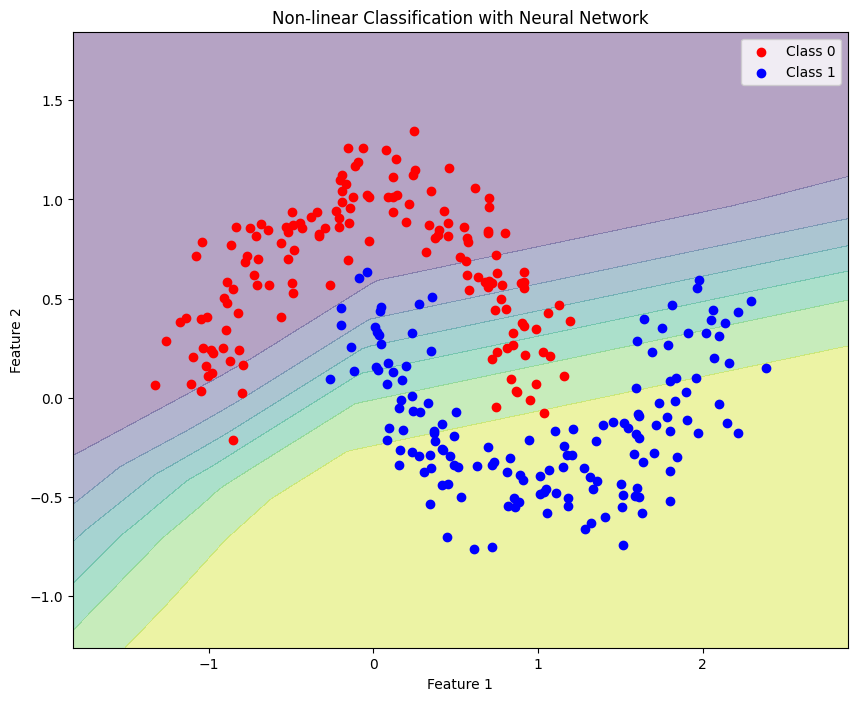

In [73]:
# Plotting
plt.figure(figsize=(10, 8))

# Create a mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Get predictions for mesh grid points
with torch.no_grad():
    Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z.numpy(), alpha=0.4)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', label='Class 1')
plt.legend()
plt.title('Non-linear Classification with Neural Network')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Tracking the NN training

Epoch 0, Loss: 0.6902
Epoch 60, Loss: 0.2316
Epoch 120, Loss: 0.0626


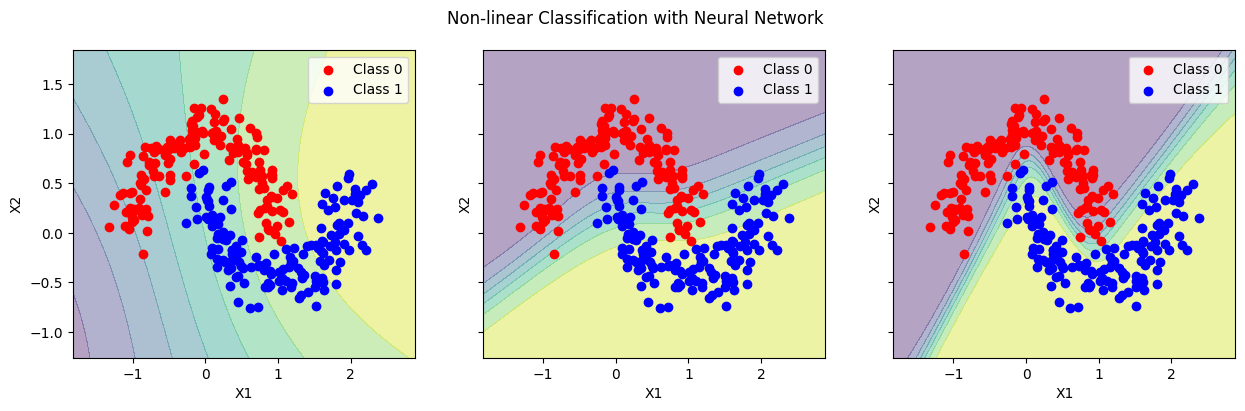

In [98]:
X = torch.FloatTensor(X)
y = torch.FloatTensor(y).reshape(-1, 1)

# Create a mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))


# Create a simple neural network with one hidden layer
model = nn.Sequential(
    nn.Linear(2, 5),  # Hidden layer with 10 units
    # nn.ReLU(),
    nn.Tanh(),
    # nn.Sigmoid(),        # Non-linear activation
    nn.Linear(5, 1),  # Output layer
    nn.Sigmoid()      # For binary classification
)

# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

i = 0
loss_list = list()

# Training loop
for epoch in range(121):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    if epoch % 60 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        # Get predictions for mesh grid points
        with torch.no_grad():
            Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
            Z = Z.reshape(xx.shape)
        
        # Plot decision boundary
        ax[i].contourf(xx, yy, Z.numpy(), alpha=0.4)
        ax[i].scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', label='Class 0')
        ax[i].scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', label='Class 1')
        ax[i].legend()
        ax[i].set_xlabel('X1')
        ax[i].set_ylabel('X2')
        i += 1

plt.suptitle('Non-linear Classification with Neural Network')
plt.show()

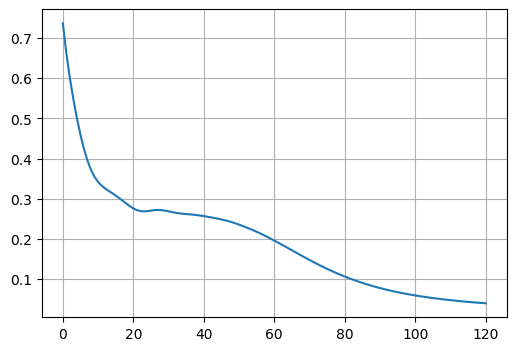

In [95]:
# loss_list
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(len(loss_list)), loss_list)
ax.grid(True)

### Non-linearity of decision boundary comes from non-linear activation functions

Beo

Epoch 0, Loss: 0.8943
Epoch 60, Loss: 0.2658
Epoch 120, Loss: 0.2653


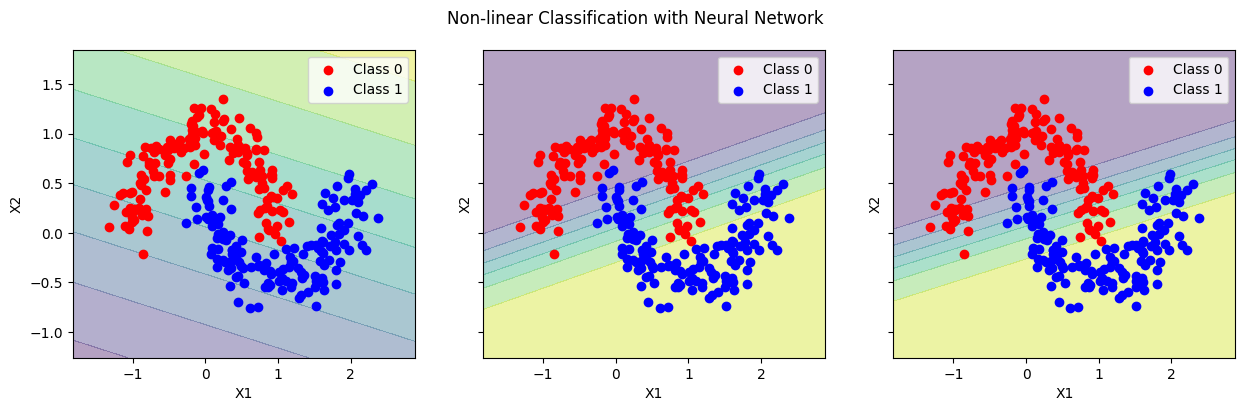

In [101]:
X = torch.FloatTensor(X)
y = torch.FloatTensor(y).reshape(-1, 1)

# Create a mesh grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))


# Create a simple neural network with one hidden layer
model = nn.Sequential(
    nn.Linear(2, 10),  # Hidden layer with 10 units
    # nn.ReLU(),
    # nn.Tanh(),
    # nn.Sigmoid(),        # Non-linear activation
    nn.Linear(10, 1),  # Output layer
    nn.Sigmoid()      # For binary classification
)

# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

i = 0
loss_list = list()

# Training loop
for epoch in range(121):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())
    if epoch % 60 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        # Get predictions for mesh grid points
        with torch.no_grad():
            Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
            Z = Z.reshape(xx.shape)
        
        # Plot decision boundary
        ax[i].contourf(xx, yy, Z.numpy(), alpha=0.4)
        ax[i].scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', label='Class 0')
        ax[i].scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', label='Class 1')
        ax[i].legend()
        ax[i].set_xlabel('X1')
        ax[i].set_ylabel('X2')
        i += 1

plt.suptitle('Non-linear Classification with Neural Network')
plt.show()

In [102]:
help(np.c_)

Help on CClass in module numpy.lib.index_tricks object:

class CClass(AxisConcatenator)
 |  Translates slice objects to concatenation along the second axis.
 |  
 |  This is short-hand for ``np.r_['-1,2,0', index expression]``, which is
 |  useful because of its common occurrence. In particular, arrays will be
 |  stacked along their last axis after being upgraded to at least 2-D with
 |  1's post-pended to the shape (column vectors made out of 1-D arrays).
 |  
 |  See Also
 |  --------
 |  column_stack : Stack 1-D arrays as columns into a 2-D array.
 |  r_ : For more detailed documentation.
 |  
 |  Examples
 |  --------
 |  >>> np.c_[np.array([1,2,3]), np.array([4,5,6])]
 |  array([[1, 4],
 |         [2, 5],
 |         [3, 6]])
 |  >>> np.c_[np.array([[1,2,3]]), 0, 0, np.array([[4,5,6]])]
 |  array([[1, 2, 3, ..., 4, 5, 6]])
 |  
 |  Method resolution order:
 |      CClass
 |      AxisConcatenator
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self)
 |     